<a href="https://colab.research.google.com/github/marwaashfaq2004-ai/AAN-.PROJECT/blob/main/ANN_PROJECT(AneRBC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install -q captum torchinfo seaborn

import os, sys, zipfile, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 7.4 MB/s eta 0:00:00
Device: cpu


# Task 1.1 - Mount Drive and extract dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')

# !! Update this path if your zip is in a subfolder !!
ZIP_PATH  = '/content/drive/MyDrive/archive.zip'
RAW_DIR   = '/content/data/bloodcells_dataset'
DATA_DIR  = '/content/data'
CLASSES   = ['basophil','eosinophil','erythroblast','ig',
             'lymphocyte','monocyte','neutrophil','platelet']
NUM_CLASSES = len(CLASSES)
IMG_SIZE  = 224
BATCH_SIZE = 32

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(RAW_DIR):
    print('Extracting zip...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print('Done.')
else:
    print('Already extracted.')

for cls in CLASSES:
    n = len(list(Path(f'{RAW_DIR}/{cls}').glob('*.jpg')))
    print(f'  {cls:20s}: {n} images')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting zip...
Done.
  basophil            : 1218 images
  eosinophil          : 3117 images
  erythroblast        : 1551 images
  ig                  : 2895 images
  lymphocyte          : 1214 images
  monocyte            : 1420 images
  neutrophil          : 3329 images
  platelet            : 2348 images


## 1.2 Data Validation

Total: 17092 | Corrupted: 0


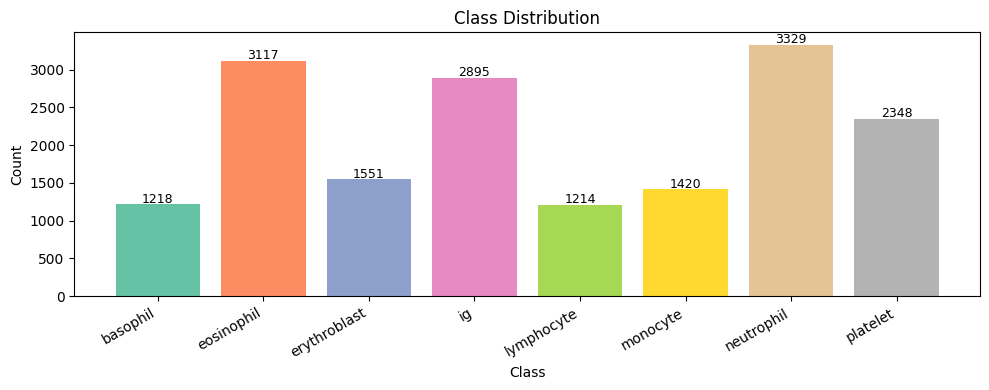

label
basophil        1218
eosinophil      3117
erythroblast    1551
ig              2895
lymphocyte      1214
monocyte        1420
neutrophil      3329
platelet        2348
Name: count, dtype: int64


In [10]:
# Task 1.2 - Validate: corruption check + class distribution

def validate_dataset(root_dir, classes):
    """
    Scan all images for corruption. Remove bad files.
    Returns DataFrame with [path, label, valid].
    """
    records, bad = [], []
    for cls in classes:
        for p in Path(root_dir).joinpath(cls).glob('*'):
            if p.suffix.lower() not in ('.jpg','.jpeg','.png'): continue
            try:
                with Image.open(p) as img: img.verify()
                records.append({'path':str(p),'label':cls,'valid':True})
            except Exception as e:
                records.append({'path':str(p),'label':cls,'valid':False})
                bad.append(str(p))
    print(f'Total: {len(records)} | Corrupted: {len(bad)}')
    for p in bad: os.remove(p)
    df = pd.DataFrame(records)
    return df[df['valid']].reset_index(drop=True)

df_all = validate_dataset(RAW_DIR, CLASSES)

# Class distribution plot
dist = df_all['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10,4))
colors = plt.cm.Set2(np.linspace(0,1,len(dist)))
bars = ax.bar(dist.index, dist.values, color=colors)
for bar,v in zip(bars,dist.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(v), ha='center', fontsize=9)
ax.set_title('Class Distribution'); ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print(dist)

## 1.3 Preprocessing Pipeline

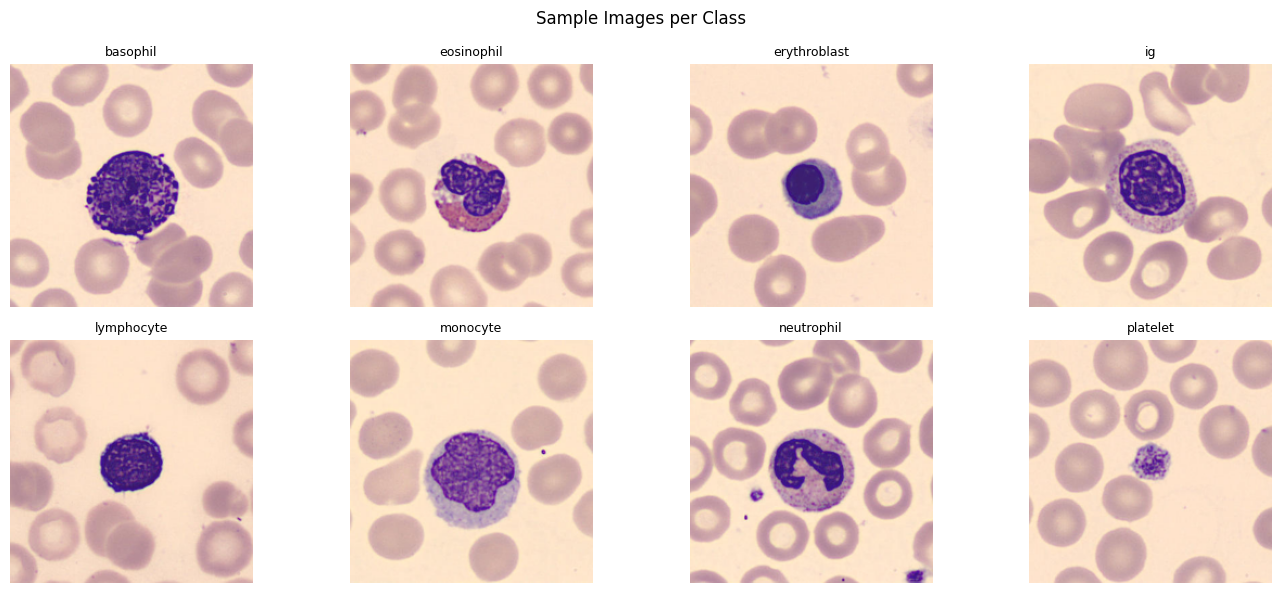

In [11]:
# Task 1.3 - Transforms: resize, normalize, augment

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Show sample images
fig, axes = plt.subplots(2,4,figsize=(14,6))
fig.suptitle('Sample Images per Class')
for ax, cls in zip(axes.flat, CLASSES):
    p = df_all[df_all['label']==cls].iloc[0]['path']
    ax.imshow(Image.open(p).convert('RGB').resize((224,224)))
    ax.set_title(cls, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## 1.4 Train/Val/Test Split & DataLoaders

In [12]:
# Task 1.4 - Stratified 70/15/15 split + DataLoaders

class BloodCellDataset(Dataset):
    """
    Custom Dataset. Input: DataFrame[path,label]. Output: (tensor, int).
    """
    def __init__(self, df, classes, transform=None):
        self.df = df.reset_index(drop=True)
        self.c2i = {c:i for i,c in enumerate(classes)}
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = Image.open(r['path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.c2i[r['label']]

# Stratified split
df_tr, df_tmp = train_test_split(df_all, test_size=0.30, stratify=df_all['label'], random_state=SEED)
df_val, df_te = train_test_split(df_tmp, test_size=0.50, stratify=df_tmp['label'], random_state=SEED)
print(f'Train:{len(df_tr)} | Val:{len(df_val)} | Test:{len(df_te)}')

train_ds = BloodCellDataset(df_tr,  CLASSES, train_transforms)
val_ds   = BloodCellDataset(df_val, CLASSES, val_test_transforms)
test_ds  = BloodCellDataset(df_te,  CLASSES, val_test_transforms)

# Weighted sampler for imbalance
lc = df_tr['label'].value_counts().sort_index()
cw = 1.0 / torch.tensor([lc[c] for c in CLASSES], dtype=torch.float)
sw = torch.tensor([cw[CLASSES.index(r)] for r in df_tr['label']])
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,  num_workers=2, pin_memory=True)
print(f'Batches -> Train:{len(train_loader)} Val:{len(val_loader)} Test:{len(test_loader)}')

Train:11964 | Val:2564 | Test:2564
Batches -> Train:374 Val:81 Test:81


# Task 2: Custom CNNs (3, 4, 5 Layers)
## 2.1 Architectures

In [ ]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES     = ['basophil','eosinophil','erythroblast','ig',
               'lymphocyte','monocyte','neutrophil','platelet']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]

print(f'Device: {DEVICE}')
if DEVICE.type=='cuda': print(f'GPU: {torch.cuda.get_device_name(0)}')
print('All imports done!')
